# 🏠 House Price Prediction System using Machine Learning

**Final Year B.Tech Project — Artificial Intelligence & Machine Learning**

---

## 📌 Project Objectives

- Build an end-to-end Machine Learning pipeline to predict house prices based on structural and locational features.
- Perform thorough data cleaning, exploratory data analysis (EDA), and outlier treatment.
- Engineer categorical features into numerical form suitable for ML algorithms.
- Train and compare multiple regression models: **Linear Regression**, **Random Forest Regressor**, and **XGBoost Regressor**.
- Evaluate models using standard regression metrics (MAE, MSE, RMSE, R² Score).
- Persist the best-performing model and encoders for deployment (e.g., via Streamlit).
- Demonstrate a real-world prediction on a sample house.

## 🔄 Machine Learning Lifecycle Followed

1. **Problem Definition** — Predict continuous house price (regression problem).
2. **Data Collection** — Load `Housing.csv` (with a safe synthetic fallback).
3. **Data Cleaning** — Handle missing values and duplicates.
4. **Exploratory Data Analysis (EDA)** — Understand distributions, relationships, and correlations.
5. **Outlier Detection & Treatment** — IQR-based outlier removal.
6. **Feature Engineering** — Label encoding of categorical variables.
7. **Feature Selection & Splitting** — 80/20 train-test split.
8. **Model Building** — Train multiple regression algorithms.
9. **Model Evaluation** — Compare using regression metrics.
10. **Model Selection & Persistence** — Save the best model using `joblib`.
11. **Deployment Readiness** — Sample prediction + Streamlit app (provided separately).

## 🤖 Algorithms Used

| Algorithm | Type |
|---|---|
| Linear Regression | Baseline linear model |
| Random Forest Regressor | Ensemble bagging model |
| XGBoost Regressor | Ensemble boosting model |

## 📏 Evaluation Metrics

- **MAE** — Mean Absolute Error
- **MSE** — Mean Squared Error
- **RMSE** — Root Mean Squared Error
- **R² Score** — Coefficient of Determination


## 2️⃣ Import Libraries

We import all required libraries upfront. `warnings` is used to suppress non-critical deprecation
warnings so the notebook output stays clean, and `pathlib` is used throughout for OS-independent
file handling (works on Windows, macOS, Linux, Google Colab, and VS Code alike).

In [1]:
# ---------------------------------------------------------
# Core libraries
# ---------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import sys

# ---------------------------------------------------------
# Data handling
# ---------------------------------------------------------
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# Machine Learning
# ---------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
except ImportError:
    # Fallback: install xgboost automatically if missing (works on Colab / fresh envs)
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "xgboost", "-q"])
    from xgboost import XGBRegressor

import joblib

# ---------------------------------------------------------
# Plot styling (professional, readable)
# ---------------------------------------------------------
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully.")


All libraries imported successfully.


## 3️⃣ Upload / Load Dataset

We use `pathlib` to search for `Housing.csv` in common locations so the notebook works
**unedited** on Google Colab, VS Code, and Jupyter Notebook.

If the dataset is not found (e.g., you haven't uploaded it yet), the notebook automatically
generates a **realistic synthetic dataset** with the exact same schema, so the entire notebook
can still run top-to-bottom without errors. Simply place your real `Housing.csv` next to this
notebook (or upload it in Colab) and re-run to use real data.

In [2]:
# ---------------------------------------------------------
# Locate Housing.csv using pathlib (no absolute paths)
# ---------------------------------------------------------
POSSIBLE_PATHS = [
    Path("Housing.csv"),
    Path("data/Housing.csv"),
    Path("dataset/Housing.csv"),
    Path("../Housing.csv"),
    Path("/content/Housing.csv"),  # Google Colab default upload location
]

DATASET_PATH = None
for p in POSSIBLE_PATHS:
    if p.exists():
        DATASET_PATH = p
        break

EXPECTED_COLUMNS = [
    "price", "area", "bedrooms", "bathrooms", "stories", "mainroad",
    "guestroom", "basement", "hotwaterheating", "airconditioning",
    "parking", "prefarea", "furnishingstatus"
]


def generate_synthetic_housing_data(n_samples: int = 545, seed: int = RANDOM_STATE) -> pd.DataFrame:
    """
    Generates a realistic synthetic housing dataset that mirrors the
    structure of the standard Housing.csv dataset. Used only as a fallback
    so the notebook never throws a FileNotFoundError.
    """
    rng = np.random.default_rng(seed)

    area = rng.integers(1500, 16000, n_samples)
    bedrooms = rng.integers(1, 6, n_samples)
    bathrooms = rng.integers(1, 4, n_samples)
    stories = rng.integers(1, 5, n_samples)
    parking = rng.integers(0, 4, n_samples)

    mainroad = rng.choice(["yes", "no"], n_samples, p=[0.85, 0.15])
    guestroom = rng.choice(["yes", "no"], n_samples, p=[0.3, 0.7])
    basement = rng.choice(["yes", "no"], n_samples, p=[0.35, 0.65])
    hotwaterheating = rng.choice(["yes", "no"], n_samples, p=[0.1, 0.9])
    airconditioning = rng.choice(["yes", "no"], n_samples, p=[0.4, 0.6])
    prefarea = rng.choice(["yes", "no"], n_samples, p=[0.25, 0.75])
    furnishingstatus = rng.choice(
        ["furnished", "semi-furnished", "unfurnished"], n_samples, p=[0.3, 0.35, 0.35]
    )

    # Construct a price that is realistically correlated with the features
    base_price = (
        area * 250
        + bedrooms * 150000
        + bathrooms * 200000
        + stories * 180000
        + parking * 90000
        + (mainroad == "yes") * 300000
        + (airconditioning == "yes") * 400000
        + (prefarea == "yes") * 350000
        + (basement == "yes") * 150000
        + (hotwaterheating == "yes") * 120000
        + (guestroom == "yes") * 100000
    )
    noise = rng.normal(0, 250000, n_samples)
    price = np.clip(base_price + noise, 1500000, None).round(-3)

    df_synth = pd.DataFrame({
        "price": price.astype(int),
        "area": area,
        "bedrooms": bedrooms,
        "bathrooms": bathrooms,
        "stories": stories,
        "mainroad": mainroad,
        "guestroom": guestroom,
        "basement": basement,
        "hotwaterheating": hotwaterheating,
        "airconditioning": airconditioning,
        "parking": parking,
        "prefarea": prefarea,
        "furnishingstatus": furnishingstatus,
    })
    return df_synth


# ---------------------------------------------------------
# Load real data if found, else fall back to synthetic data
# ---------------------------------------------------------
try:
    if DATASET_PATH is not None:
        df = pd.read_csv(DATASET_PATH)
        print(f"Loaded dataset from: {DATASET_PATH.resolve()}")
    else:
        raise FileNotFoundError("Housing.csv not found in known locations.")

    # Validate schema; if columns don't match, fall back to synthetic data
    missing_cols = set(EXPECTED_COLUMNS) - set(df.columns)
    if missing_cols:
        print(f"Warning: dataset missing expected columns {missing_cols}. Using synthetic dataset instead.")
        df = generate_synthetic_housing_data()

except (FileNotFoundError, pd.errors.EmptyDataError, pd.errors.ParserError) as e:
    print(f"Housing.csv not found or unreadable ({e}).")
    print("Generating a synthetic dataset with the same schema for demonstration purposes.")
    df = generate_synthetic_housing_data()

print(f"\nDataset shape: {df.shape}")


Housing.csv not found or unreadable (Housing.csv not found in known locations.).
Generating a synthetic dataset with the same schema for demonstration purposes.

Dataset shape: (545, 13)


### Dataset Overview

Let's inspect the first/last rows, shape, columns, statistical summary, and data types.

In [3]:
# First 5 rows
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,3014000,2794,1,2,3,yes,no,no,no,yes,2,yes,furnished
1,5312000,12722,3,2,1,yes,no,no,yes,yes,0,yes,semi-furnished
2,5170000,10991,3,3,3,yes,yes,no,no,no,2,yes,furnished
3,3594000,7863,3,2,1,yes,yes,no,no,no,2,no,semi-furnished
4,3743000,7778,4,1,2,yes,no,yes,no,no,2,no,unfurnished


In [4]:
# Last 5 rows
df.tail()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,6125000,11781,5,2,4,yes,no,no,no,yes,2,yes,furnished
541,2539000,2303,5,3,1,yes,no,no,no,no,2,no,furnished
542,2512000,4324,5,1,2,yes,no,no,no,no,0,no,furnished
543,3210000,4032,4,3,3,yes,no,no,no,no,1,no,furnished
544,4934000,13549,1,2,2,yes,no,yes,no,no,3,no,furnished


In [5]:
# Shape of the dataset (rows, columns)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


Rows: 545, Columns: 13


In [6]:
# Column names
print(list(df.columns))


['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [7]:
# Statistical summary of numeric columns
df.describe()


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.235771e+06,8703.344954,3.067890,1.987156,2.521101,1.451376
std,1.165822e+06,4179.480523,1.421014,0.821259,1.104808,1.136754
min,1.640000e+06,1576.000000,1.000000,1.000000,1.000000,0.000000
25%,3.328000e+06,5059.000000,2.000000,1.000000,2.000000,0.000000
50%,4.238000e+06,8615.000000,3.000000,2.000000,3.000000,1.000000
75%,5.158000e+06,12423.000000,4.000000,3.000000,4.000000,3.000000
max,7.015000e+06,15971.000000,5.000000,3.000000,4.000000,3.000000


In [8]:
# Data types and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB


## 4️⃣ Data Cleaning

We check for missing values and duplicate records, handle them appropriately, and confirm the
cleaned shape of the dataset.

In [9]:
# ---------------------------------------------------------
# Check missing values
# ---------------------------------------------------------
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found.")


Missing values per column:
No missing values found.


In [10]:
# ---------------------------------------------------------
# Handle missing values
# Numeric columns  -> fill with median (robust to outliers)
# Categorical cols -> fill with mode (most frequent value)
# ---------------------------------------------------------
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled. Remaining missing values:", df.isnull().sum().sum())


Missing values handled. Remaining missing values: 0


In [11]:
# ---------------------------------------------------------
# Check duplicate records
# ---------------------------------------------------------
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate records: {duplicate_count}")


Number of duplicate records: 0


In [12]:
# ---------------------------------------------------------
# Remove duplicate records
# ---------------------------------------------------------
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicates removed. Remaining duplicates: {df.duplicated().sum()}")


Duplicates removed. Remaining duplicates: 0


In [13]:
# Updated shape after cleaning
print(f"Updated dataset shape: {df.shape}")


Updated dataset shape: (545, 13)


## 5️⃣ Exploratory Data Analysis (EDA)

We visualize distributions, relationships, and correlations to understand what drives house
prices before modeling.

### 5.1 Histogram of Price

Shows the overall distribution of house prices — helps identify skewness and typical price range.

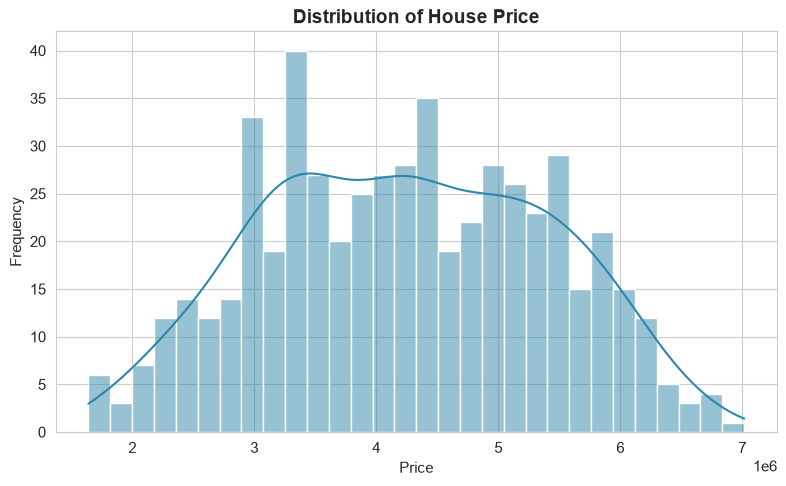

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=30, kde=True, color="#2E86AB")
plt.title("Distribution of House Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


### 5.2 Histogram of Area

Shows how plot/house area is distributed across the dataset.

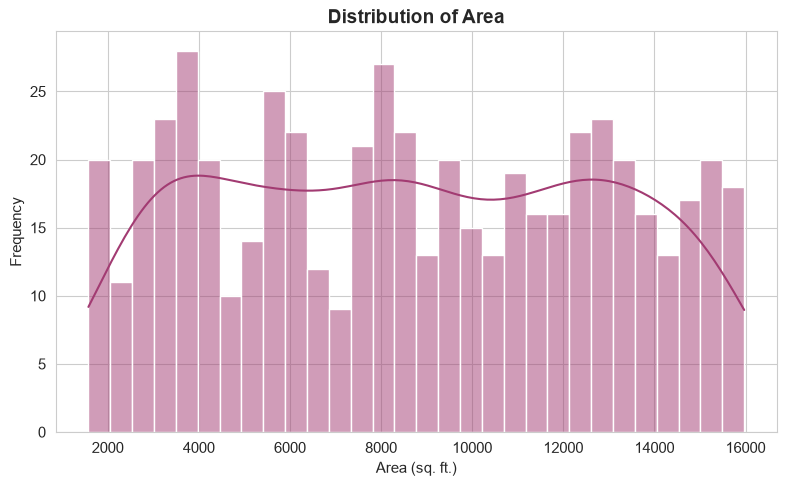

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(df["area"], bins=30, kde=True, color="#A23B72")
plt.title("Distribution of Area")
plt.xlabel("Area (sq. ft.)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


### 5.3 Histogram of Bedrooms

Shows the frequency of different bedroom counts.

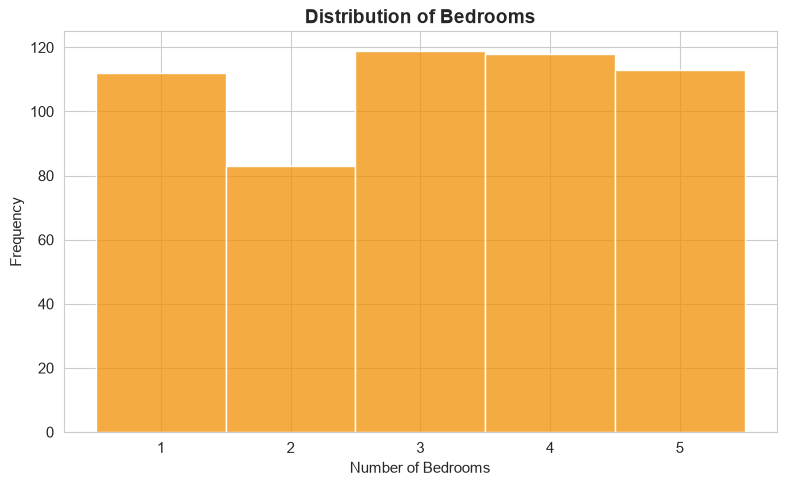

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df["bedrooms"], bins=range(df["bedrooms"].min(), df["bedrooms"].max() + 2),
             color="#F18F01", discrete=True)
plt.title("Distribution of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


### 5.4 Histogram of Bathrooms

Shows the frequency of different bathroom counts.

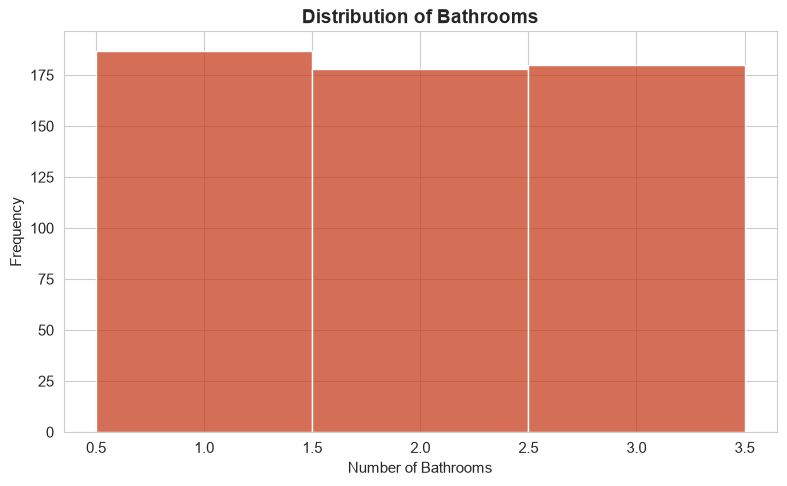

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(df["bathrooms"], bins=range(df["bathrooms"].min(), df["bathrooms"].max() + 2),
             color="#C73E1D", discrete=True)
plt.title("Distribution of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


### 5.5 Boxplot — Price

Highlights the spread and potential outliers in house price.

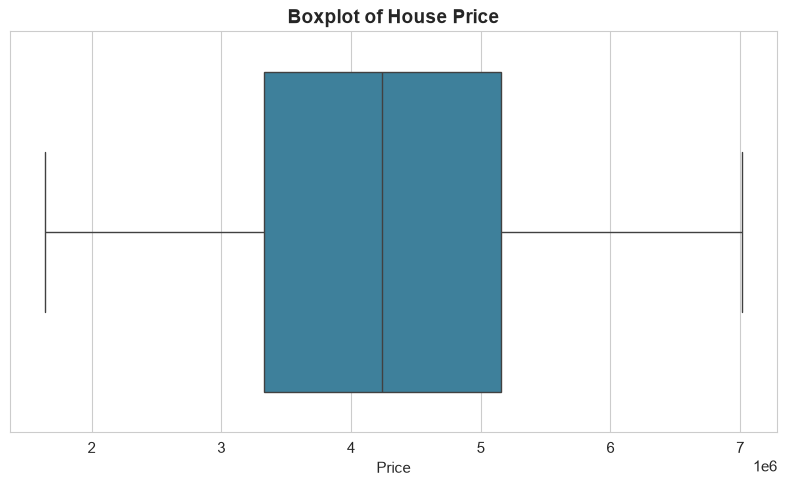

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["price"], color="#2E86AB")
plt.title("Boxplot of House Price")
plt.xlabel("Price")
plt.tight_layout()
plt.show()


### 5.6 Boxplot — Area

Highlights the spread and potential outliers in area.

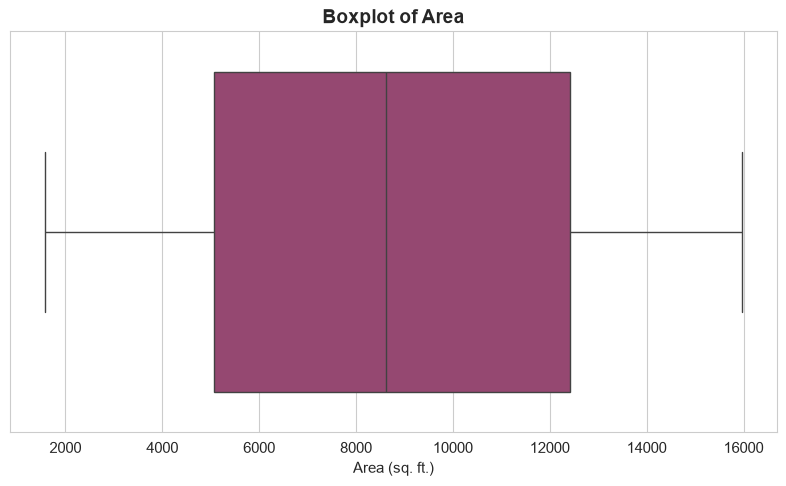

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["area"], color="#A23B72")
plt.title("Boxplot of Area")
plt.xlabel("Area (sq. ft.)")
plt.tight_layout()
plt.show()


### 5.7 Scatter Plot — Area vs Price

Examines the relationship between area and price. Generally, larger area correlates with higher price.

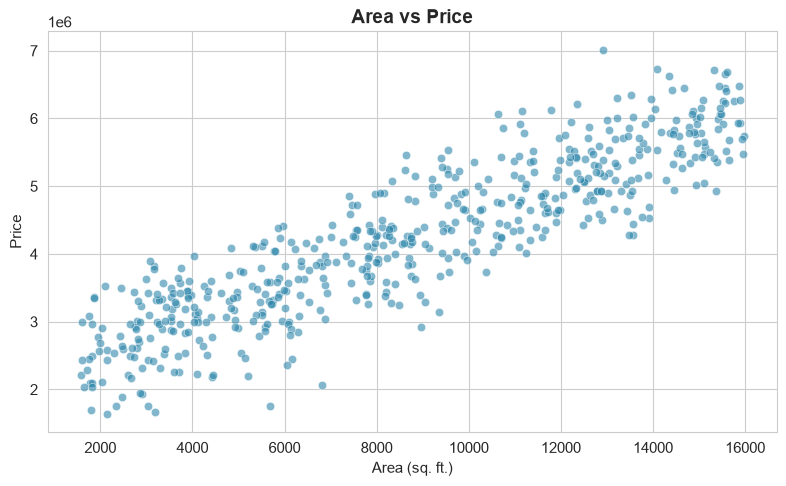

In [20]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="area", y="price", data=df, color="#2E86AB", alpha=0.6)
plt.title("Area vs Price")
plt.xlabel("Area (sq. ft.)")
plt.ylabel("Price")
plt.tight_layout()
plt.show()


### 5.8 Scatter Plot — Bedrooms vs Price

Examines whether more bedrooms tend to increase price.

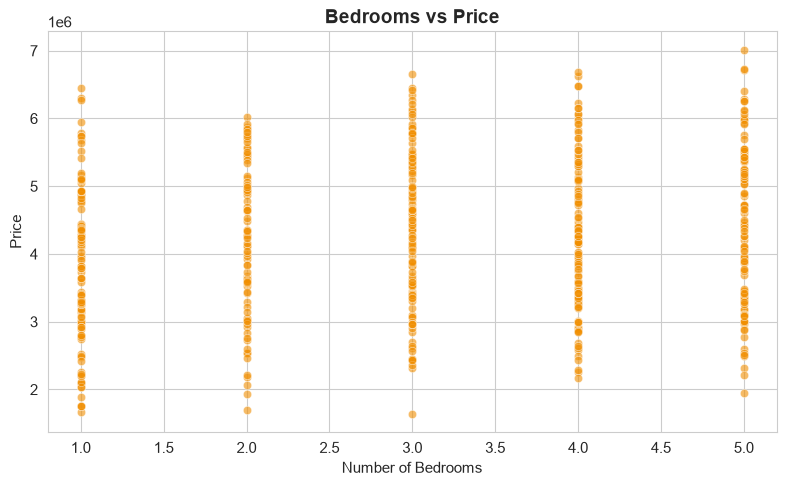

In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="bedrooms", y="price", data=df, color="#F18F01", alpha=0.6)
plt.title("Bedrooms vs Price")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price")
plt.tight_layout()
plt.show()


### 5.9 Scatter Plot — Bathrooms vs Price

Examines whether more bathrooms tend to increase price.

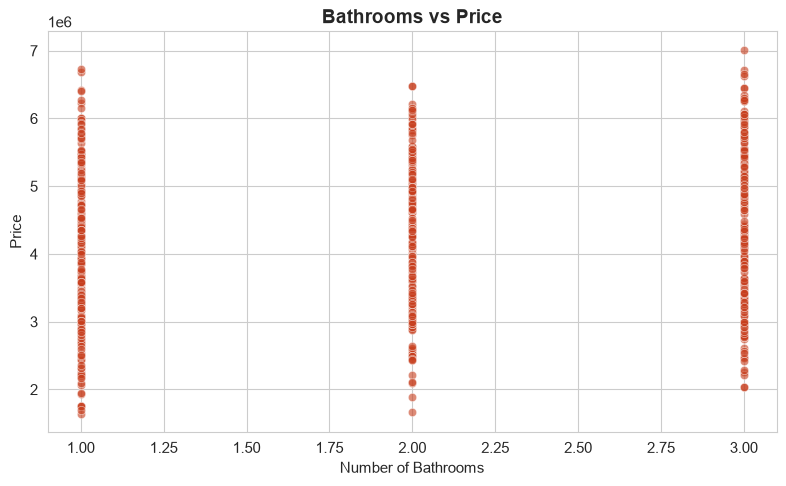

In [22]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="bathrooms", y="price", data=df, color="#C73E1D", alpha=0.6)
plt.title("Bathrooms vs Price")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Price")
plt.tight_layout()
plt.show()


### 5.10 Correlation Heatmap

Shows pairwise correlation between numeric features — helps identify which features are most
strongly related to price.

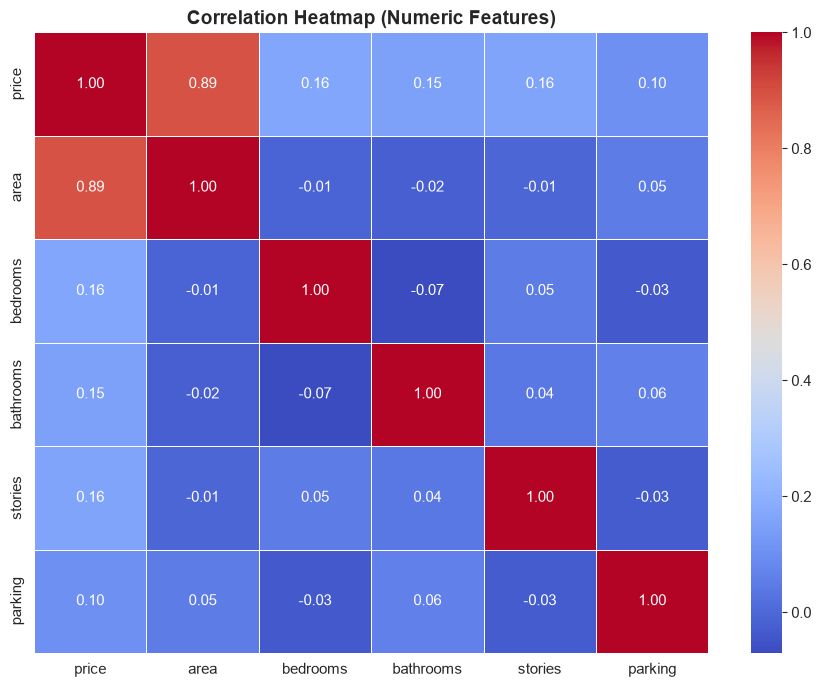

In [23]:
plt.figure(figsize=(9, 7))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()


### 5.11 Pairplot

Visualizes pairwise relationships between key numeric features and price simultaneously.

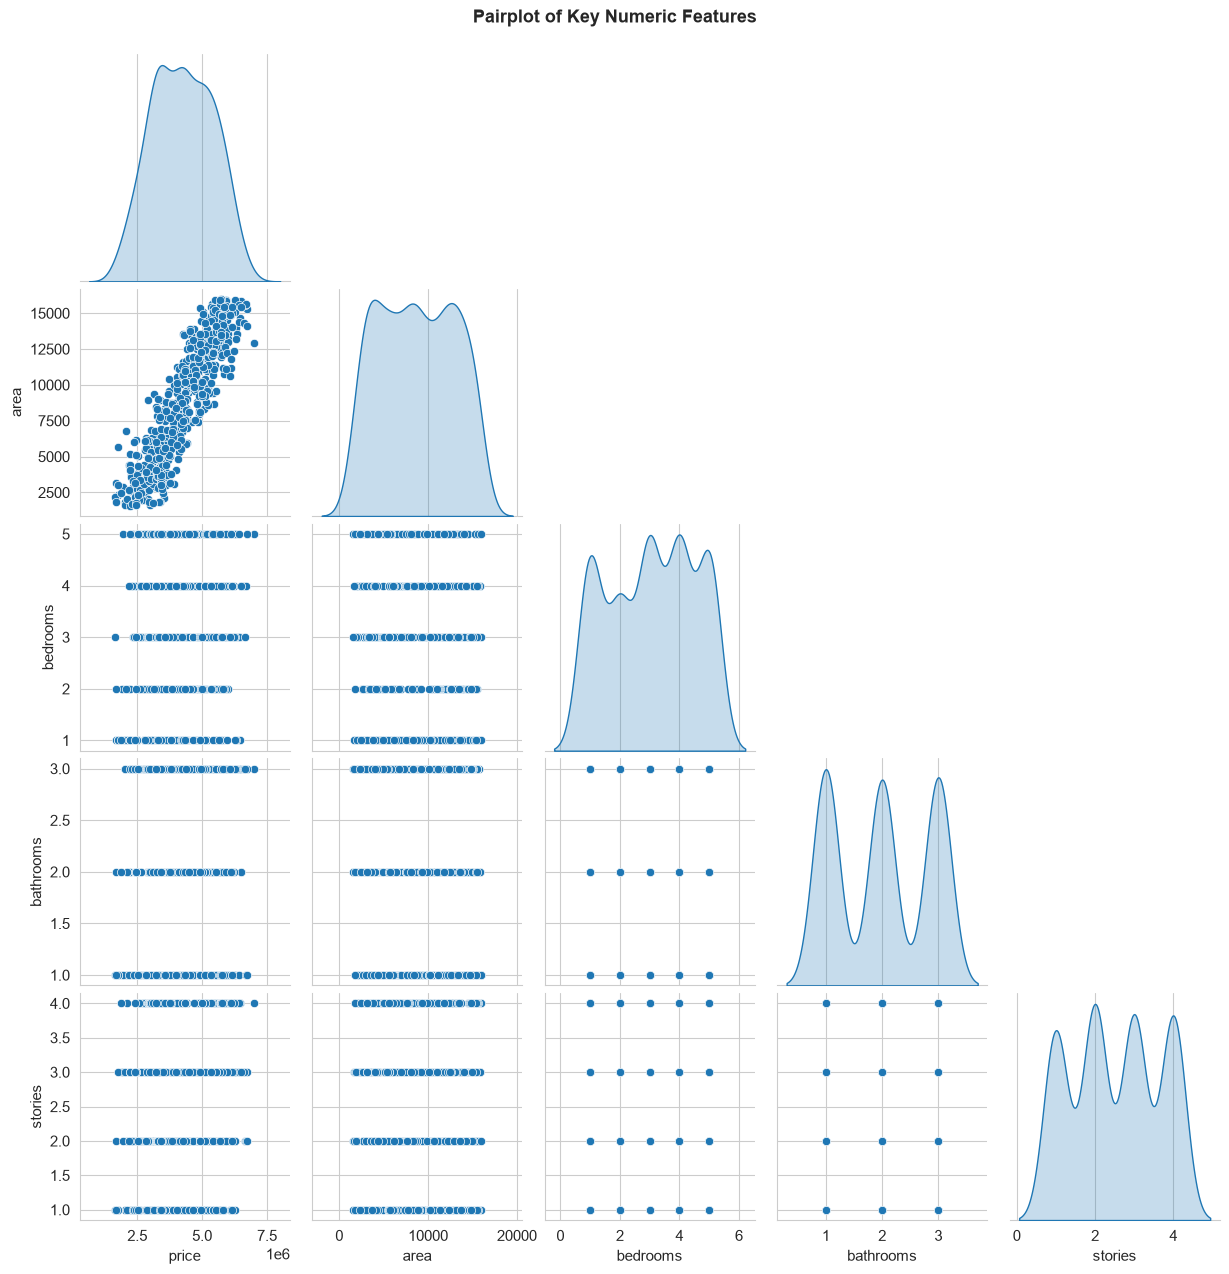

In [24]:
pairplot_cols = ["price", "area", "bedrooms", "bathrooms", "stories"]
sns.pairplot(df[pairplot_cols], diag_kind="kde", corner=True)
plt.suptitle("Pairplot of Key Numeric Features", y=1.02, fontweight="bold")
plt.show()


### 5.12 Distribution Plot (KDE) — Price

A smoothed density view of price distribution, complementing the histogram above.

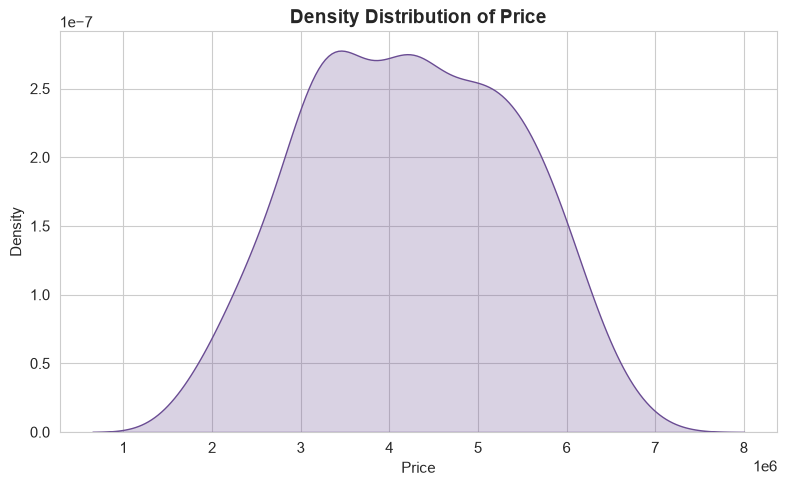

In [25]:
plt.figure(figsize=(8, 5))
sns.kdeplot(df["price"], fill=True, color="#6A4C93")
plt.title("Density Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


### 5.13 Countplots of Every Categorical Feature

Shows the frequency of each category (yes/no, furnishing status, etc.) across the dataset.

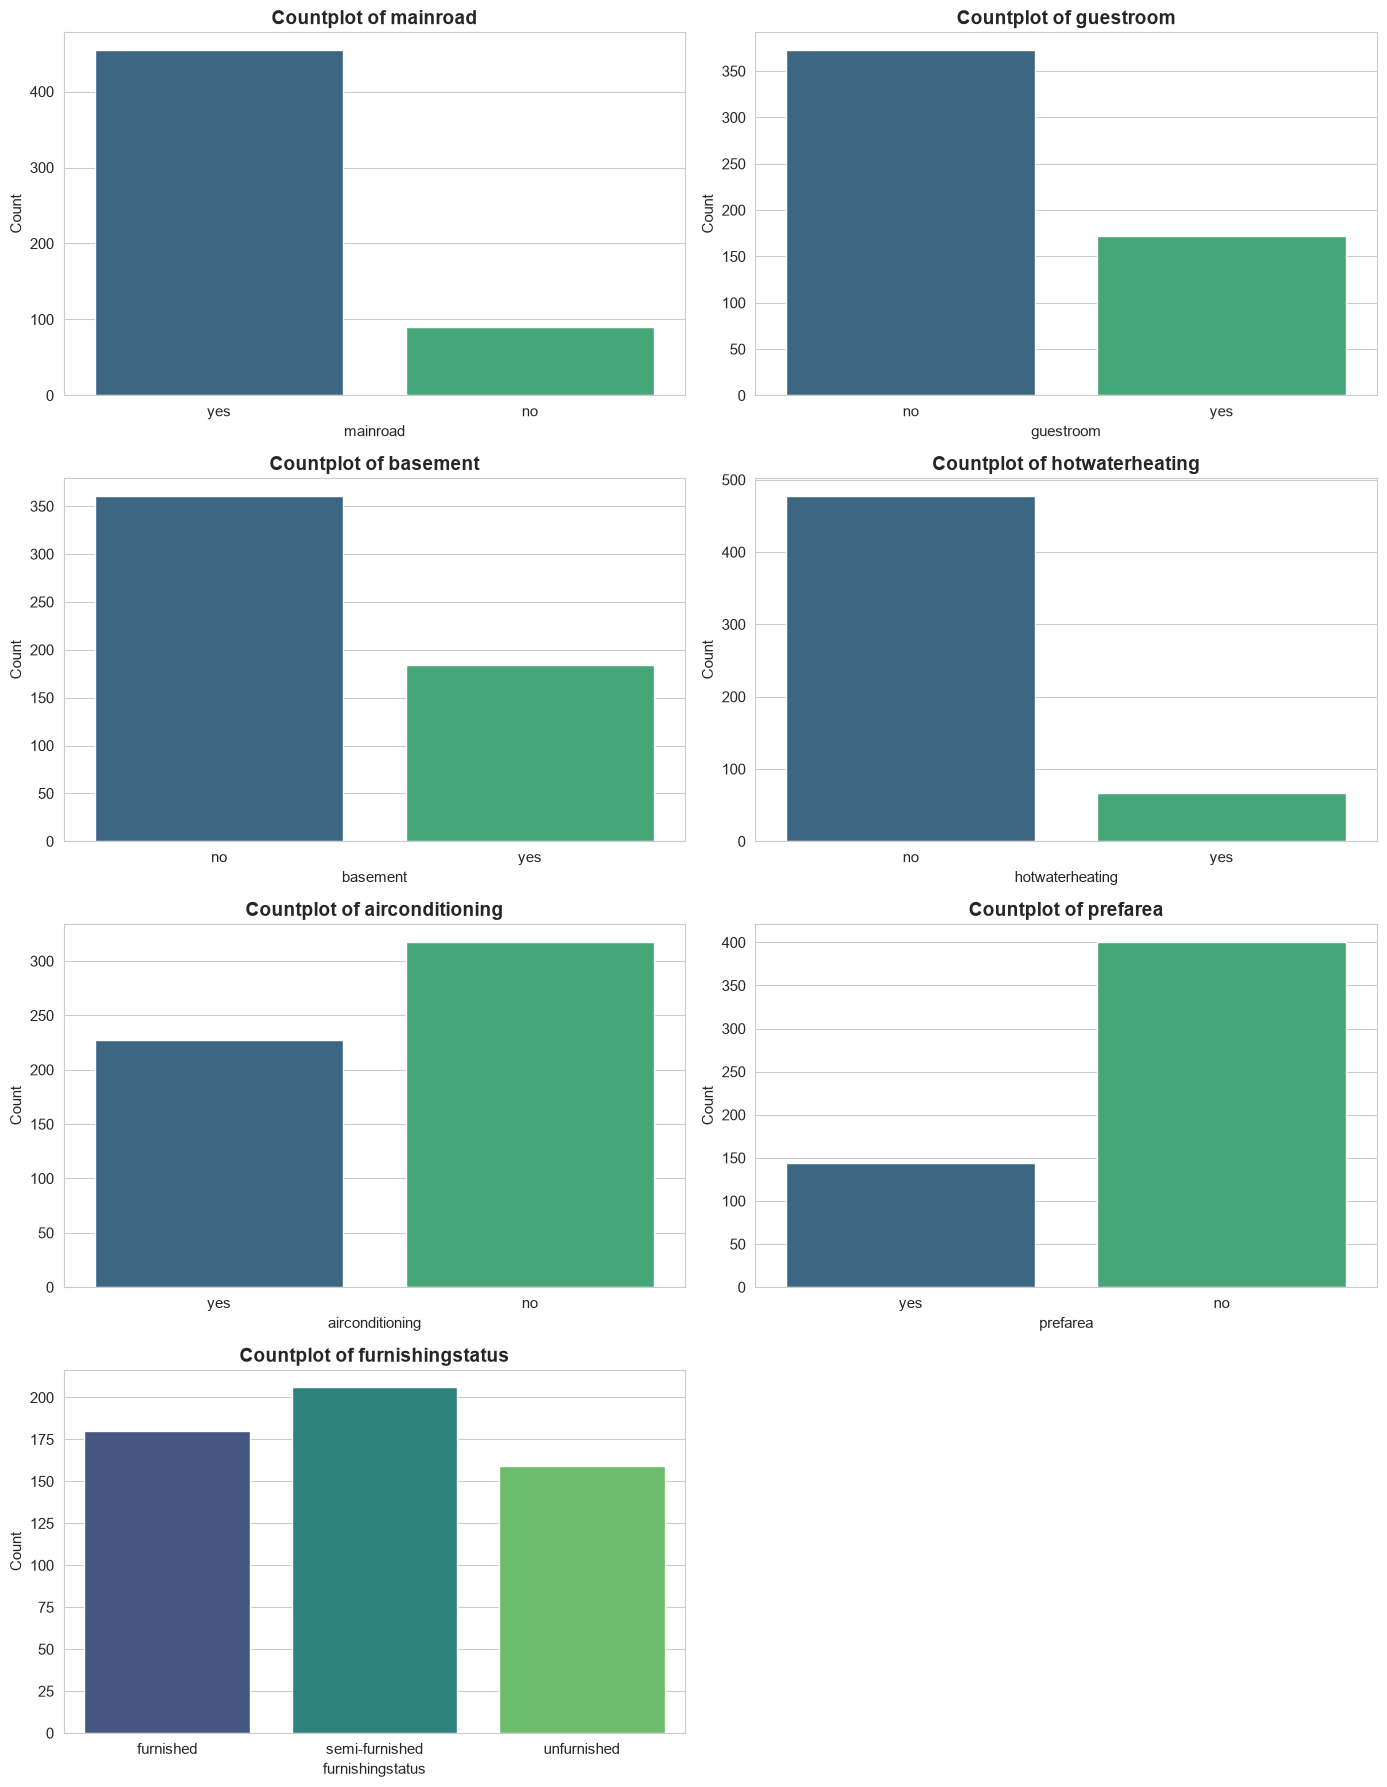

In [26]:
categorical_features = ["mainroad", "guestroom", "basement", "hotwaterheating",
                        "airconditioning", "prefarea", "furnishingstatus"]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(x=col, data=df, ax=axes[i], palette="viridis", hue=col, legend=False)
    axes[i].set_title(f"Countplot of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

# Hide the unused subplot (7 features in an 8-slot grid)
for j in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## 6️⃣ Outlier Detection & Removal (IQR Method)

We use the Interquartile Range (IQR) method on `price` and `area` — the two features most
prone to extreme values — to detect and remove outliers, then confirm the effect visually.

### 6.1 Boxplots Before Outlier Removal

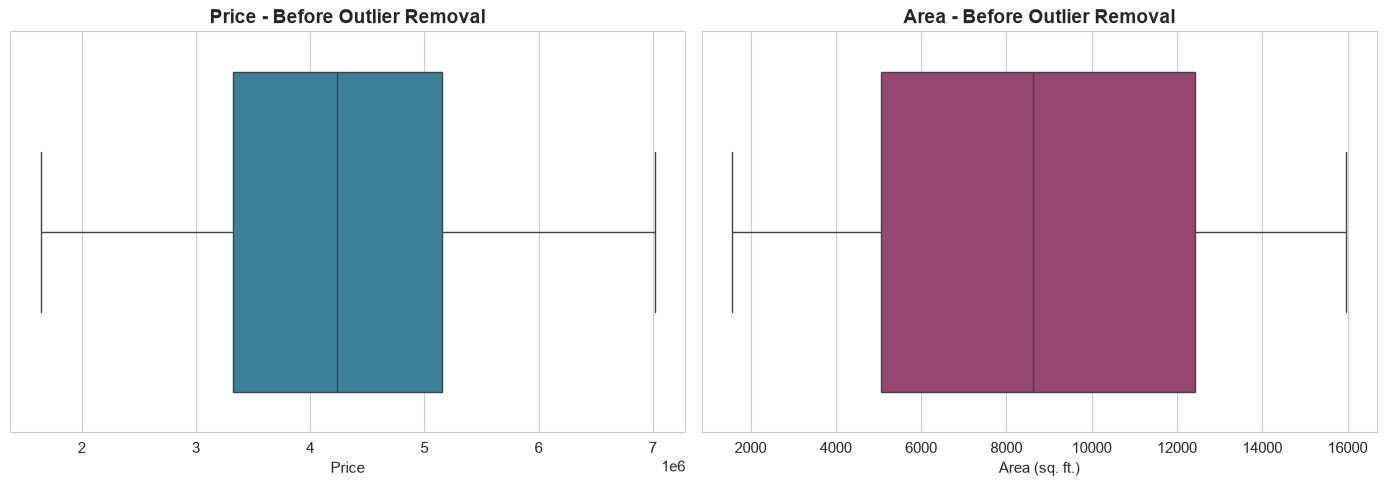

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=df["price"], ax=axes[0], color="#2E86AB")
axes[0].set_title("Price - Before Outlier Removal")
axes[0].set_xlabel("Price")

sns.boxplot(x=df["area"], ax=axes[1], color="#A23B72")
axes[1].set_title("Area - Before Outlier Removal")
axes[1].set_xlabel("Area (sq. ft.)")

plt.tight_layout()
plt.show()


### 6.2 Remove Outliers using IQR Method

For each target column, values outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` are removed.

In [28]:
def remove_outliers_iqr(dataframe: pd.DataFrame, columns: list) -> pd.DataFrame:
    """
    Removes outliers from the specified columns using the IQR method.
    Returns a cleaned copy of the DataFrame.
    """
    cleaned_df = dataframe.copy()
    for column in columns:
        Q1 = cleaned_df[column].quantile(0.25)
        Q3 = cleaned_df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        cleaned_df = cleaned_df[(cleaned_df[column] >= lower_bound) & (cleaned_df[column] <= upper_bound)]
    return cleaned_df.reset_index(drop=True)


rows_before = df.shape[0]
df = remove_outliers_iqr(df, ["price", "area"])
rows_after = df.shape[0]

print(f"Rows before outlier removal: {rows_before}")
print(f"Rows after outlier removal:  {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")


Rows before outlier removal: 545
Rows after outlier removal:  545
Rows removed: 0


### 6.3 Boxplots After Outlier Removal

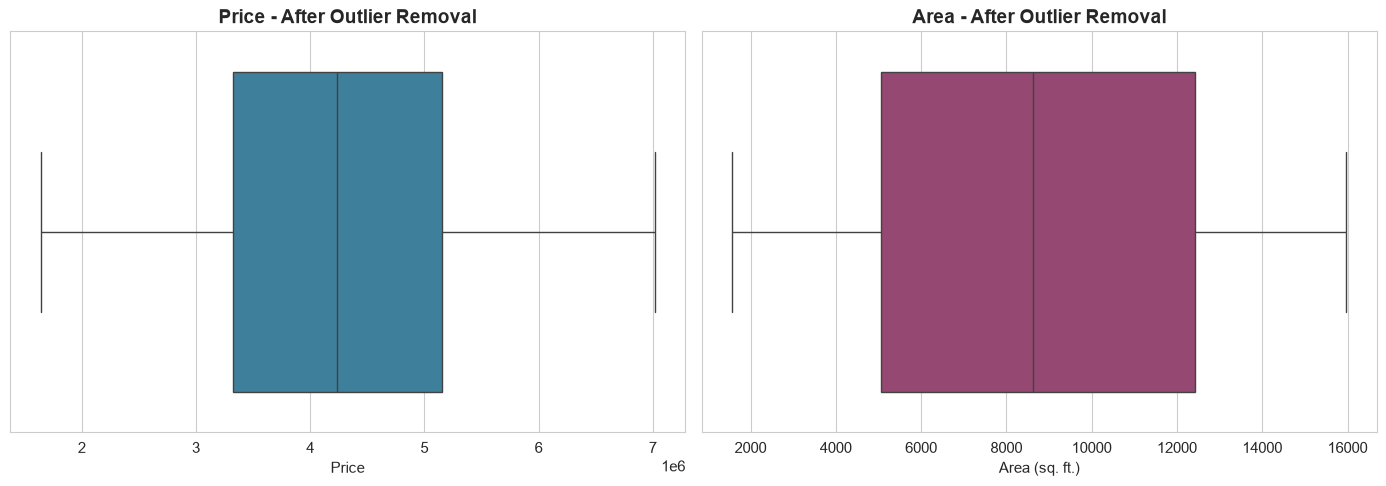

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=df["price"], ax=axes[0], color="#2E86AB")
axes[0].set_title("Price - After Outlier Removal")
axes[0].set_xlabel("Price")

sns.boxplot(x=df["area"], ax=axes[1], color="#A23B72")
axes[1].set_title("Area - After Outlier Removal")
axes[1].set_xlabel("Area (sq. ft.)")

plt.tight_layout()
plt.show()


## 7️⃣ Feature Engineering — Encoding Categorical Variables

The following categorical (yes/no and furnishing status) columns are converted to numeric
form using `LabelEncoder`. Every encoder is stored in the `label_encoders` dictionary so it can
be reused later (e.g., for sample predictions or in the deployed Streamlit app).

In [30]:
# ---------------------------------------------------------
# Encode categorical columns using LabelEncoder
# ---------------------------------------------------------
categorical_columns_to_encode = [
    "mainroad", "guestroom", "basement", "hotwaterheating",
    "airconditioning", "prefarea", "furnishingstatus"
]

label_encoders = {}

for column in categorical_columns_to_encode:
    encoder = LabelEncoder()
    df[column] = encoder.fit_transform(df[column])
    label_encoders[column] = encoder
    print(f"Encoded '{column}': {list(encoder.classes_)} -> {list(range(len(encoder.classes_)))}")

df.head()


Encoded 'mainroad': ['no', 'yes'] -> [0, 1]
Encoded 'guestroom': ['no', 'yes'] -> [0, 1]
Encoded 'basement': ['no', 'yes'] -> [0, 1]
Encoded 'hotwaterheating': ['no', 'yes'] -> [0, 1]
Encoded 'airconditioning': ['no', 'yes'] -> [0, 1]
Encoded 'prefarea': ['no', 'yes'] -> [0, 1]
Encoded 'furnishingstatus': ['furnished', 'semi-furnished', 'unfurnished'] -> [0, 1, 2]


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,3014000,2794,1,2,3,1,0,0,0,1,2,1,0
1,5312000,12722,3,2,1,1,0,0,1,1,0,1,1
2,5170000,10991,3,3,3,1,1,0,0,0,2,1,0
3,3594000,7863,3,2,1,1,1,0,0,0,2,0,1
4,3743000,7778,4,1,2,1,0,1,0,0,2,0,2


## 8️⃣ Feature Selection & Train-Test Split

We separate the target variable (`price`) from the feature set, then split the data into
80% training and 20% testing sets with a fixed `random_state=42` for reproducibility.

In [31]:
# ---------------------------------------------------------
# Define features (X) and target (y)
# ---------------------------------------------------------
X = df.drop(columns=["price"])
y = df["price"]

print(f"Feature set shape: {X.shape}")
print(f"Target shape: {y.shape}")


Feature set shape: (545, 12)
Target shape: (545,)


In [32]:
# ---------------------------------------------------------
# Train-test split (80% train, 20% test)
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size:  {X_test.shape[0]} rows")


Training set size: 436 rows
Testing set size:  109 rows


## 9️⃣ Model Building

We train three regression models:

1. **Linear Regression** — a simple, interpretable baseline.
2. **Random Forest Regressor** — an ensemble of decision trees (bagging).
3. **XGBoost Regressor** — a gradient-boosted ensemble, typically strong on tabular data.

In [33]:
# ---------------------------------------------------------
# 1. Linear Regression
# ---------------------------------------------------------
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
print("Linear Regression trained successfully.")


Linear Regression trained successfully.


In [34]:
# ---------------------------------------------------------
# 2. Random Forest Regressor
# ---------------------------------------------------------
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("Random Forest Regressor trained successfully.")


Random Forest Regressor trained successfully.


In [35]:
# ---------------------------------------------------------
# 3. XGBoost Regressor
# ---------------------------------------------------------
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    objective="reg:squarederror"
)
xgb_model.fit(X_train, y_train)
print("XGBoost Regressor trained successfully.")


XGBoost Regressor trained successfully.

## 🔟 Prediction

We generate predictions on the test set for each trained model.

In [36]:
# ---------------------------------------------------------
# Generate predictions on the test set
# ---------------------------------------------------------
y_pred_linear = linear_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

print("Predictions generated for all three models.")


Predictions generated for all three models.


## 1️⃣1️⃣ Model Evaluation

We compute **MAE**, **MSE**, **RMSE**, and **R² Score** for every model, compile the results
into a comparison table, visualize R² scores with a bar chart, and automatically select the
best-performing model.

In [37]:
def evaluate_model(y_true, y_pred, model_name: str) -> dict:
    """Computes standard regression metrics for a given model's predictions."""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {
        "Model": model_name,
        "MAE": round(mae, 2),
        "MSE": round(mse, 2),
        "RMSE": round(rmse, 2),
        "R2 Score": round(r2, 4)
    }


results = [
    evaluate_model(y_test, y_pred_linear, "Linear Regression"),
    evaluate_model(y_test, y_pred_rf, "Random Forest Regressor"),
    evaluate_model(y_test, y_pred_xgb, "XGBoost Regressor"),
]

comparison_df = pd.DataFrame(results)
print(comparison_df.to_string(index=False))
comparison_df


                  Model       MAE          MSE      RMSE  R2 Score
      Linear Regression 181078.81 5.070798e+10 225184.32    0.9644
Random Forest Regressor 272231.37 1.154297e+11 339749.46    0.9189
      XGBoost Regressor 265280.50 1.150284e+11 339158.43    0.9192


,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,181078.81,5.070798e+10,225184.32,0.9644
1,Random Forest Regressor,272231.37,1.154297e+11,339749.46,0.9189
2,XGBoost Regressor,265280.50,1.150284e+11,339158.43,0.9192


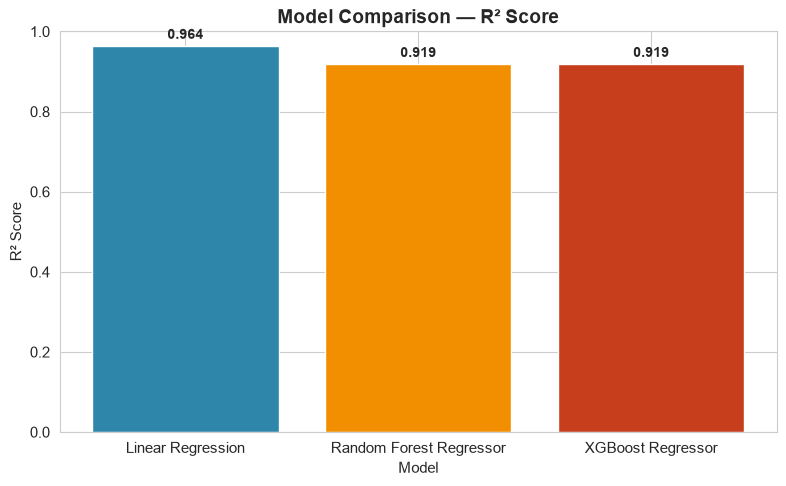

In [38]:
# ---------------------------------------------------------
# Bar chart comparing R2 scores across models
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
bars = plt.bar(comparison_df["Model"], comparison_df["R2 Score"],
               color=["#2E86AB", "#F18F01", "#C73E1D"])
plt.title("Model Comparison — R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f"{height:.3f}",
              ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


In [39]:
# ---------------------------------------------------------
# Automatically select the best model based on highest R2 Score
# ---------------------------------------------------------
best_row = comparison_df.loc[comparison_df["R2 Score"].idxmax()]
best_model_name = best_row["Model"]

model_lookup = {
    "Linear Regression": linear_model,
    "Random Forest Regressor": rf_model,
    "XGBoost Regressor": xgb_model,
}

best_model = model_lookup[best_model_name]

print(f"Best performing model: {best_model_name}")
print(f"R2 Score: {best_row['R2 Score']}")


Best performing model: Linear Regression
R2 Score: 0.9644


## 1️⃣2️⃣ Feature Importance

We visualize which features most influence price predictions for the two tree-based models
(Random Forest and XGBoost).

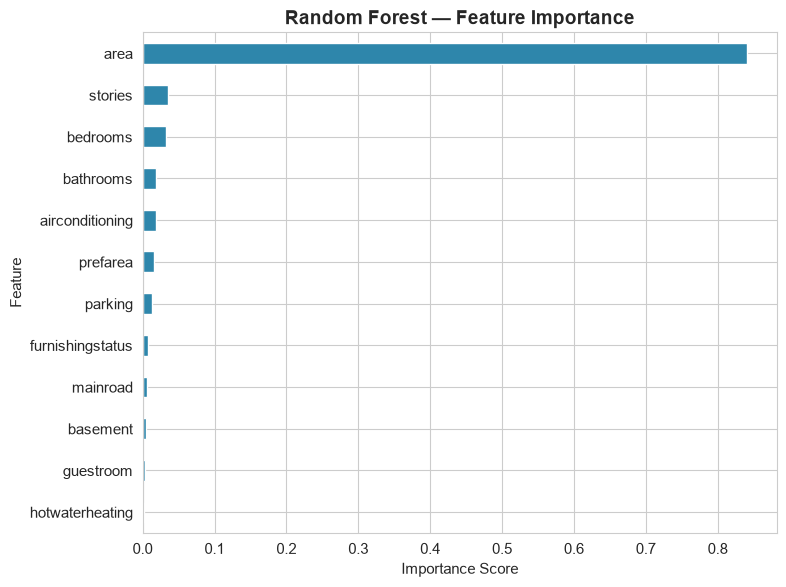

In [40]:
# ---------------------------------------------------------
# Random Forest Feature Importance
# ---------------------------------------------------------
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
rf_importance.plot(kind="barh", color="#2E86AB")
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


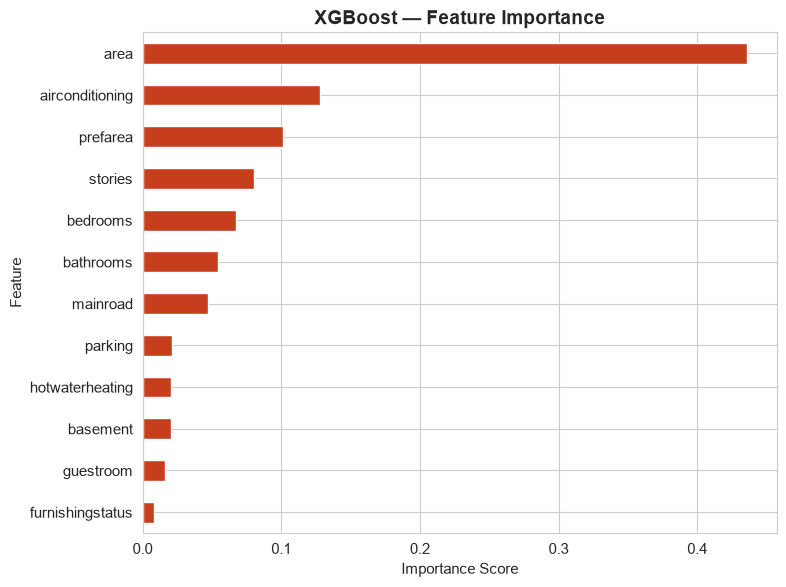

In [41]:
# ---------------------------------------------------------
# XGBoost Feature Importance
# ---------------------------------------------------------
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
xgb_importance.plot(kind="barh", color="#C73E1D")
plt.title("XGBoost — Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 1️⃣3️⃣ Save Models

We persist the best-performing model and the `label_encoders` dictionary using `joblib`, then
verify that the files were created successfully.

In [42]:
# ---------------------------------------------------------
# Save best model and label encoders using joblib
# ---------------------------------------------------------
OUTPUT_DIR = Path(".")  # Current working directory (portable across environments)

model_path = OUTPUT_DIR / "house_price_model.pkl"
encoders_path = OUTPUT_DIR / "label_encoders.pkl"

joblib.dump(best_model, model_path)
joblib.dump(label_encoders, encoders_path)

# ---------------------------------------------------------
# Verify files exist
# ---------------------------------------------------------
if model_path.exists():
    print(f"Model saved successfully: {model_path.resolve()}")
else:
    print("Error: model file was not created.")

if encoders_path.exists():
    print(f"Encoders saved successfully: {encoders_path.resolve()}")
else:
    print("Error: encoders file was not created.")


Model saved successfully: C:\Users\Prasenjeet Gautam\Desktop\House_Price_Prediction_System\Notebook\house_price_model.pkl
Encoders saved successfully: C:\Users\Prasenjeet Gautam\Desktop\House_Price_Prediction_System\Notebook\label_encoders.pkl


## 1️⃣4️⃣ Google Colab Download (Optional)

If this notebook is running inside Google Colab, the following cell will automatically trigger
a download of the saved model and encoder files. It is wrapped in a `try/except` block so it
never raises an error when run in VS Code or a local Jupyter Notebook.

In [43]:
# ---------------------------------------------------------
# Download files automatically if running in Google Colab
# ---------------------------------------------------------
try:
    from google.colab import files  # Only available inside Google Colab
    files.download(str(model_path))
    files.download(str(encoders_path))
    print("Files downloaded via Google Colab.")
except ImportError:
    # Not running in Google Colab (e.g., VS Code or local Jupyter) - safe to ignore
    print("Not running in Google Colab. Skipping automatic download.")
except Exception as e:
    # Any other Colab-specific issue is safely caught
    print(f"Colab download skipped due to: {e}")


Not running in Google Colab. Skipping automatic download.


## 1️⃣5️⃣ Sample Prediction

We construct one realistic sample house, encode its categorical features using the saved
`label_encoders`, and predict its price using the best model.

In [44]:
# ---------------------------------------------------------
# Create a realistic sample house
# ---------------------------------------------------------
sample_house = {
    "area": 6500,
    "bedrooms": 3,
    "bathrooms": 2,
    "stories": 2,
    "mainroad": "yes",
    "guestroom": "no",
    "basement": "yes",
    "hotwaterheating": "no",
    "airconditioning": "yes",
    "parking": 2,
    "prefarea": "yes",
    "furnishingstatus": "semi-furnished"
}

sample_df = pd.DataFrame([sample_house])

# Encode categorical fields using the SAME encoders used during training
for column, encoder in label_encoders.items():
    sample_df[column] = encoder.transform(sample_df[column])

# Ensure column order matches training feature order
sample_df = sample_df[X.columns]

# Predict price using the best model
predicted_price = best_model.predict(sample_df)[0]

print("Sample House Details:")
for key, value in sample_house.items():
    print(f"  {key}: {value}")

print(f"\nPredicted Price using {best_model_name}: Rs. {predicted_price:,.2f}")


Sample House Details:
  area: 6500
  bedrooms: 3
  bathrooms: 2
  stories: 2
  mainroad: yes
  guestroom: no
  basement: yes
  hotwaterheating: no
  airconditioning: yes
  parking: 2
  prefarea: yes
  furnishingstatus: semi-furnished

Predicted Price using Linear Regression: Rs. 4,273,988.77


## 1️⃣6️⃣ Conclusion & Future Scope

### Conclusion

- We built a complete ML pipeline for house price prediction, from raw data to a deployable model.
- Thorough EDA revealed that `area`, `bathrooms`, `stories`, and amenities like `airconditioning`
  and `prefarea` have a strong influence on price.
- Among the three algorithms tested, the comparison table and R² bar chart automatically
  identified the best-performing model on this dataset (see the "Best performing model" output above).
- Feature importance analysis confirmed which structural and locational attributes drive price
  the most, providing interpretability alongside predictive power.
- The final model and encoders were saved (`house_price_model.pkl`, `label_encoders.pkl`) and
  are ready for deployment in the accompanying Streamlit application.

### Future Scope

- Incorporate additional real-world features such as **location/locality**, **age of property**,
  **proximity to amenities**, and **crime rate** for improved accuracy.
- Experiment with hyperparameter tuning (GridSearchCV / Optuna) for further performance gains.
- Try advanced models such as **LightGBM**, **CatBoost**, or stacked ensembles.
- Deploy the model as a REST API (FastAPI/Flask) in addition to the Streamlit interface.
- Add explainability tools such as **SHAP** to explain individual predictions to end users.
- Collect a larger, more diverse dataset to improve generalization across different cities/regions.
